# 7. Explainability (SHAP)

Attribution for the fitted models. Read this stage with the collinearity diagnostics from
stage 03 in mind: where features correlate above 0.95, SHAP splits credit between them
arbitrarily, so individual rankings inside those blocks are not identifiable even though
the block totals are.

## 7.1 Environment and cached inputs

Loads `_shared.py` (paths, the artifact cache helpers, the target definitions) and applies the thesis figure style, then prints the artifact cache so it is visible which upstream stage produced these inputs and when. Reads the random forests stage 04 fitted, so nothing is refitted here.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd() if (Path.cwd() / "_shared.py").exists() else Path.cwd() / "notebooks"))
from _shared import *  # noqa: F401,F403  paths, artifact cache, target bounds

from src.evaluation import figures as fx
fx.apply_thesis_style()

print("stage inputs available in the artifact cache:")
print(artifact_status().to_string(index=False) if len(artifact_status()) else "  (none yet)")

dataset = load_frame("dataset")
spec = load_json("feature_spec")
FEATURE_COLS, TARGET_COLS = spec["FEATURE_COLS"], spec["TARGET_COLS"]
X = dataset[FEATURE_COLS].fillna(spec.get("MEDIAN_IMPUTE_VALUES", {})).fillna(0.0)
# Global-median fill (methodology-audit finding #14), matching how
# final_rf_models.pkl was actually fit (notebook 04's X_global_imputed) --
# SHAP must explain the model on the SAME inputs it was trained on, not a
# different (zero-filled) version of them.
y = dataset[TARGET_COLS].copy()
selected_features = load_object("selected_features")
final_rf_models = load_object("final_rf_models")
rf_y1 = final_rf_models[TARGET_COLS[0]]  # refit on all real rows in stage 04
print(f"loaded fitted models for: {sorted(final_rf_models)}")


stage inputs available in the artifact cache:
                     artifact               written_utc rows                                                                                                                                                                                  note
       ablation_block_contrib 2026-09-16T20:43:36+00:00   60                                                                                                                                 Paired-bootstrap contribution of each external block.
              ablation_blocks 2026-09-16T20:43:28+00:00   72                                                                                                                                             Pooled R2/RMSE per external-block config.
       classification_summary 2026-09-16T20:54:35+00:00   20                                                                                                                                     Pre-registered binary labels, po

## 7.2 Global feature importance

Thesis §3.8.2 / blueprint Step 9 agree on this. TreeSHAP applied to the Random Forest's Y1 (ASPI) estimator, both globally (what drives predictions across all events) and locally (one real historical event, not Ditwah — it isn't in the modeled set, see §5).

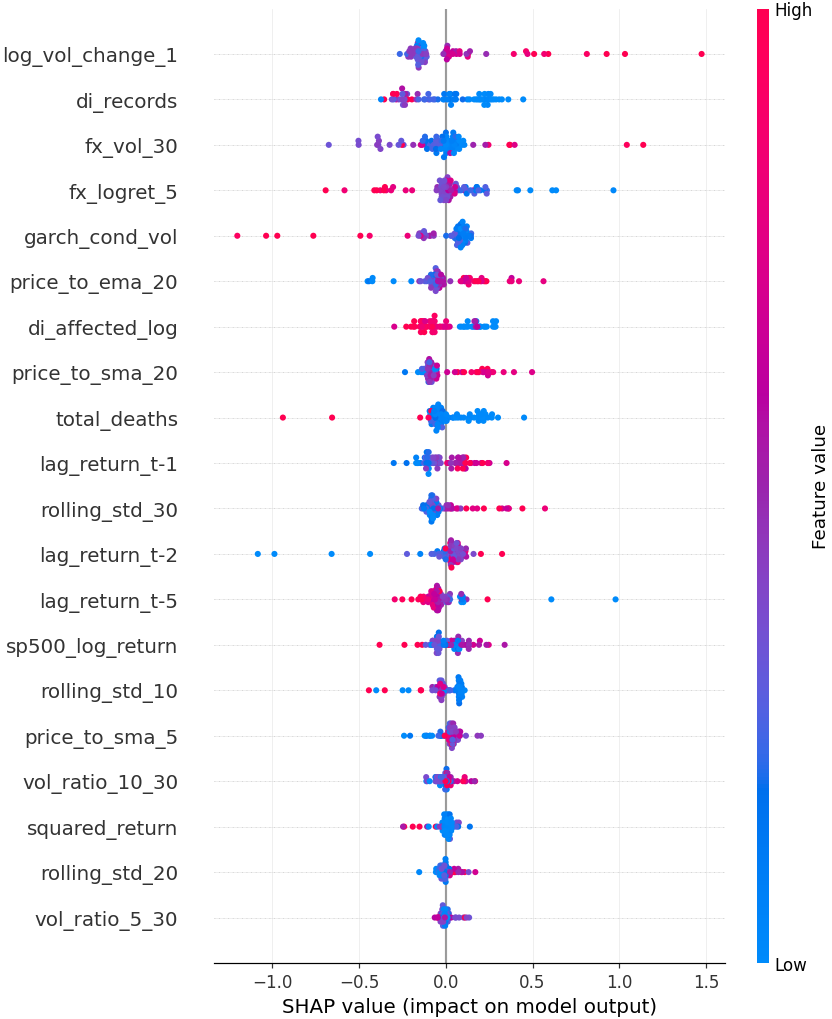

In [2]:
import shap

# Y1's own selected feature set from the last walk-forward fold (\u00a79's
# per-target feature selection) -- SHAP must be computed on exactly the
# columns rf_y1 was actually trained on. Explained over the real 64 events
# only (X, not any SMOGN output) -- SMOGN's synthetic rows exist only inside
# each fold's training step now, never as a standing dataset to explain.
y1_features = selected_features[TARGET_COLS[0]]
X_y1 = X[y1_features]

explainer = shap.TreeExplainer(rf_y1)
shap_values = explainer.shap_values(X_y1)

shap.summary_plot(shap_values, X_y1, show=False)


### 7.2.1 Render the summary plot

SHAP draws onto the active matplotlib figure, so the export is a separate call.

In [3]:
import matplotlib.pyplot as plt
plt.tight_layout()
plt.show()


<Figure size 693x396 with 0 Axes>

## 7.3 Local explanation for a single event

A waterfall for one real modelled event — the largest ASPI drop in the training set.
Read it as attribution after the fact, not as a forecast: several of the features
contributing to it are damage assessments finalised weeks after the event.

Explaining event row: 1 Y1 = -7.203286544195688


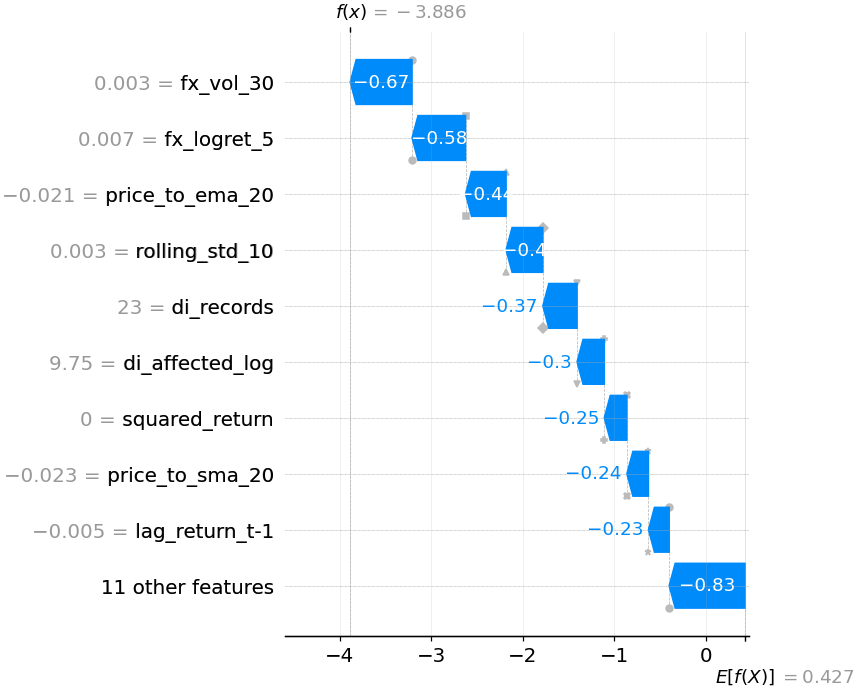

In [4]:
# Local explanation for one real, modeled event (largest ASPI drop in the training set)
worst_idx = int(y["Y1_ASPI_5D_Forward_LogReturn_Pct"].idxmin())
print("Explaining event row:", worst_idx, "Y1 =", y.loc[worst_idx, "Y1_ASPI_5D_Forward_LogReturn_Pct"])

explanation = shap.Explanation(
    values=shap_values[worst_idx], base_values=explainer.expected_value,
    data=X_y1.iloc[worst_idx], feature_names=X_y1.columns.tolist(),
)
shap.plots.waterfall(explanation, show=False)
plt.tight_layout()
plt.show()
